In [24]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from uncertainties import ufloat

In [25]:
stroeme = np.arange(0.1, 1.1, 0.1)
max_raten = []

for strom in stroeme:
    sheet_name = f"A5.{str(int(strom*10))}"
    
    df_temp = pd.read_excel("data/xst.xlsx", sheet_name=sheet_name)

    max_rate = df_temp["R"].max()
    max_rate_per_sec = max_rate / 4
    max_raten.append(max_rate_per_sec)

fit_data = pd.DataFrame({"I": stroeme, "R_max": max_raten})
fit_data

,I,R_max
0,0.1,98.375
1,0.2,184.375
2,0.3,262.825
3,0.4,334.250
4,0.5,404.125
5,0.6,468.375
6,0.7,538.700
7,0.8,588.950
8,0.9,653.625
9,1.0,693.750


In [26]:
# Statistische Unsicherheit der Zählrate (Poisson)
delta_t = 4.0 # s laut Aufgabe 5 
y_err = np.sqrt(fit_data["R_max"] / delta_t)

def dead_time_model(I, r, tau):
    return r * I * np.exp(-r * tau * I)

# 2. Startwerte (p0) schätzen
# r: Anfangssteigung (R_Z / I), tau: ca. 200 Mikrosekunden
p0 = [fit_data["R_max"].iloc[0] / fit_data["I"].iloc[0], 200e-6]

popt, pcov = curve_fit(
    dead_time_model, 
    fit_data["I"], 
    fit_data["R_max"], 
    p0=[max_raten[0]/stroeme[0], 200e-6],
    sigma=y_err,         # Hier fließen die Unsicherheiten ein
    absolute_sigma=True  # Wichtig für korrekte Fehlerfortpflanzung
)
r_fit, tau_fit = popt

perr = np.sqrt(np.diag(pcov))

# popt[0] ist r, popt[1] ist tau
r_u = ufloat(popt[0], perr[0])
tau_u = ufloat(popt[1], perr[1])

tau_u_mus = tau_u * 1e6

# :.2uP sorgt für eine Rundung der Unsicherheit auf zwei Stellen 
# und nutzt das Plus-Minus-Zeichen
print(f"Proportionalitätskonstante r: {r_u:.2uP} 1/(mA*s)")
print(f"Detektor-Totzeit tau: {tau_u_mus:.2uP} µs")

Proportionalitätskonstante r: 967±22 1/(mA*s)
Detektor-Totzeit tau: 344±25 µs


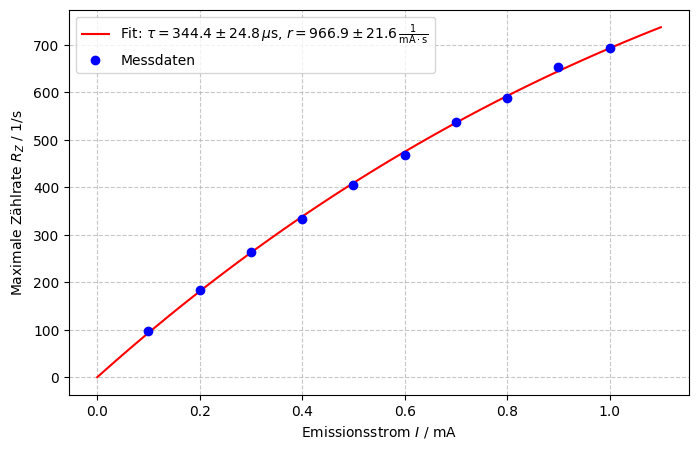

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

I_smooth = np.linspace(0, 1.1, 100)
ax.plot(I_smooth, dead_time_model(I_smooth, *popt), 'r-', 
        label=rf"Fit: $\tau = {tau_u_mus:.1fL}\,\mu\mathrm{{s}}$, $r = {r_u:.1fL}\,\frac{{1}}{{\mathrm{{mA \cdot s}}}}$")

ax.plot(fit_data["I"], fit_data["R_max"], 'bo', label="Messdaten")

ax.set_xlabel("Emissionsstrom $I$ / mA")
ax.set_ylabel("Maximale Zählrate $R_Z$ / 1/s")
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()